# 503: Decomposition and waterfall plot

Produces the decomposition waterfall plot and corresponding table, for the four
drivers of post-NZCO2 GSAT change investigated. The deltas are always computed on the
real per-member runs first (i.e. same member/parameter draw contributing to both the
NZCO2-year and 2100 values, so every component's delta is internally consistent and
the exact per-member decomposition `ANTHROPOGENIC = CO2_NZCO2 + CO2_Negative +
NonCO2_GHG + Residual` holds), the aggregation across scenario then matches 501's 
convention, taking the medians across scenarios at each quantile level (p17/p50/p83).

This is deliberately NOT the same as 501's own "delta-of-quantile-trajectory"
construction for its GSAT-change section - that computes the quantile of the
NZCO2-year value and the quantile of the 2100 value separately (each an
independent cross-sectional ranking of the 600 members), then subtracts (can produce
a non-monotonic "likely range" (p83 < p17) for small, mixed-sign components). It works
in 501 (classifying scenarios by climate-response realization, where a single large coherent 
signal - total ANTHROPOGENIC warming is being ranked), but it's the wrong tool for a 
decomposition where the whole point is each component's actual, internally-consistent 
contribution for the same real member.

Quantile-of-delta doesn't have this problem: each per-scenario p17/p50/p83 is a real member's 
own delta (or an interpolation between two real members), so `p17 <= p50 <= p83` holds by 
construction for every scenario - and since `median(X_i) <= median(Y_i)` whenever 
`X_i <= Y_i` for every i, that ordering survives the median-across-scenarios step too. 
Guaranteed monotonic, not just empirically so.

Outputs:
- `503_Figure_3.png`
- `503_Table_Figure_3.png`

In [19]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dotenv.load_dotenv()

# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

MANIFEST_ID = "regenerated"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

## Load Per-Member Component Metrics

`500b_component_metrics_extended` already has every component's (ANTHROPOGENIC,
CO2_NZCO2, CO2_Negative, NonCO2_GHG, Residual) own real per-member delta
(`delta_netzero_co2`), computed on that same real member - plus the absolute
NZCO2-year and 2100 values for ANTHROPOGENIC, needed for the two endpoint bars.


In [20]:
metrics_df = pd.read_csv(METRICS_FILE, index_col=0)

COMPONENTS = ["ANTHROPOGENIC", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]
DELTA_COMPONENTS = ["CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]
group_counts = (
    metrics_df
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .size()
    .reindex(groups)
)
print(group_counts)

scenario_group
Scenarios (NZCO2)                 784
Scenarios (NZGHG)                 387
Stylised Variants (NZCO2-hold)    784
Stylised Variants (NZGHG-hold)    387
dtype: int64


## Aggregation: Quantile-of-Delta per Scenario, Then Median Across Scenarios

For the two **endpoint bars**: per scenario, the quantile across members of the real
per-member ANTHROPOGENIC value at that one year (NZCO2 or 2100) - a single column,
no subtraction, so always well-ordered on its own.

For the four **component bars**: per scenario, the quantile across members of that
component's real per-member delta (already computed member-by-member in 500b) -
again a single column of real per-member numbers, so `p17 <= p50 <= p83` holds by
construction.

Either way, the very last step is the same: **median across scenarios** of each
quantile level, matching 501's own aggregation convention.


In [21]:
QLEVELS = {"p17": 0.17, "p50": 0.5, "p83": 0.83}


def scenario_quantiles_then_median(metrics_df, column, groups):
    """For one real per-member column (a delta, or an absolute value - doesn't
    matter, it's never subtracted against a separately-ranked column): per-scenario
    quantile across members at p17/p50/p83, then median across scenarios of each
    level. Guaranteed monotonic (p17 <= p50 <= p83), since it never compares two
    independently-sorted quantities."""
    results = {}
    for group in groups:
        gdf = metrics_df[metrics_df["scenario_group"] == group]
        scen_q = gdf.groupby(["model", "scenario"])[column].agg(
            **{lv: (lambda x, q=q: x.quantile(q)) for lv, q in QLEVELS.items()}
        )
        results[group] = scen_q.median()
    return results


# Endpoint bars: absolute ANTHROPOGENIC value at each of the two years.
endpoint_stats = {
    "nzco2": scenario_quantiles_then_median(metrics_df, "GSAT|ANTHROPOGENIC|netzero_co2", groups),
    "y2100": scenario_quantiles_then_median(metrics_df, "GSAT|ANTHROPOGENIC|2100", groups),
}

# Component bars: each component's real per-member delta (ANTHROPOGENIC's own delta
# computed the same way too, for the additivity sanity check below).
delta_stats = {
    comp: scenario_quantiles_then_median(metrics_df, f"GSAT|{comp}|delta_netzero_co2", groups)
    for comp in COMPONENTS
}

# Sanity check: do the four component deltas sum to the ANTHROPOGENIC delta?
for group in groups:
    comp_sum = sum(delta_stats[c][group]["p50"] for c in DELTA_COMPONENTS)
    anthro = delta_stats["ANTHROPOGENIC"][group]["p50"]
    print(f"{group:35s} components sum={comp_sum:.4f}  ANTHROPOGENIC={anthro:.4f}  diff={abs(comp_sum - anthro):.4f}")

# Monotonicity check: p17 <= p50 <= p83 for every component/group, as guaranteed.
for comp in COMPONENTS:
    for group in groups:
        s = delta_stats[comp][group]
        assert s["p17"] <= s["p50"] <= s["p83"], (comp, group, s.to_dict())
print("\nAll component deltas monotonic (p17 <= p50 <= p83) - confirmed.")

Scenarios (NZCO2)                   components sum=-0.1010  ANTHROPOGENIC=-0.1110  diff=0.0101
Scenarios (NZGHG)                   components sum=-0.1842  ANTHROPOGENIC=-0.1926  diff=0.0084
Stylised Variants (NZCO2-hold)      components sum=-0.0425  ANTHROPOGENIC=-0.0432  diff=0.0007
Stylised Variants (NZGHG-hold)      components sum=-0.1497  ANTHROPOGENIC=-0.1488  diff=0.0009

All component deltas monotonic (p17 <= p50 <= p83) - confirmed.


## Waterfall Plot (501-Style Aggregation)

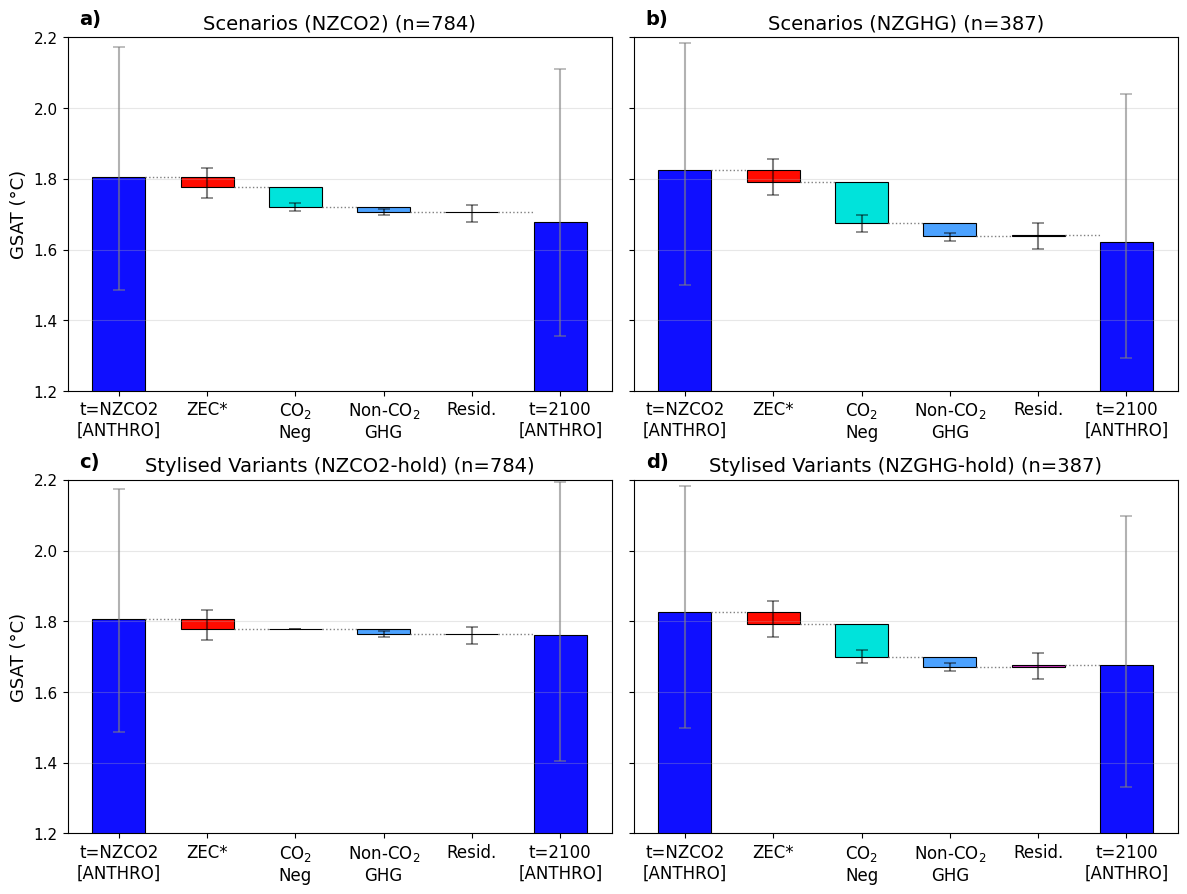

In [22]:
def create_waterfall_plot_501style(group, title, ax):
    color_start = '#0F0FFF'
    color_delta = {
        'CO2_NZCO2': '#FF0B00',
        'CO2_Negative': '#00E3DB',
        'NonCO2_GHG': '#4CA2FF',
        'Residual': '#C92EB9'
    }
    color_end = '#0F0FFF'

    # Endpoint error bars are gray, distinct from the component error bars (black) -
    # a visual cue that they represent a different kind of uncertainty (within-
    # scenario climate-response spread) than the components' own (quantile-of-delta,
    # much narrower) error bars.
    error_kw = {'ecolor': 'black', 'alpha': 0.5, 'capsize': 4, 'capthick': 1.2}
    error_kw_endpoint = {'ecolor': 'gray', 'alpha': 0.6, 'capsize': 4, 'capthick': 1.2}
    bar_kw = {'width': 0.6, 'edgecolor': 'black', 'linewidth': 0.8}

    nzco2 = endpoint_stats["nzco2"][group]
    y2100 = endpoint_stats["y2100"][group]

    x_positions = [0, 1, 2, 3, 4, 5]
    labels = ["t=NZCO2\n[ANTHRO]", "ZEC*", "CO$_2$\nNeg", "Non-CO$_2$\nGHG", "Resid.", "t=2100\n[ANTHRO]"]

    ax.bar(0, nzco2["p50"], color=color_start,
           yerr=[[nzco2["p50"] - nzco2["p17"]], [nzco2["p83"] - nzco2["p50"]]],
           error_kw=error_kw_endpoint, **bar_kw)

    bottom = nzco2["p50"]
    boundaries = [nzco2["p50"]]
    half_width = bar_kw["width"] / 2
    connector_kw = {"linestyle": ":", "color": "gray", "linewidth": 1, "zorder": 1}

    for i, comp in enumerate(DELTA_COMPONENTS):
        delta = delta_stats[comp][group]

        ax.bar(i + 1, delta["p50"], bottom=bottom, color=color_delta[comp],
               yerr=[[delta["p50"] - delta["p17"]], [delta["p83"] - delta["p50"]]],
               error_kw=error_kw, **bar_kw)
        bottom += delta["p50"]
        boundaries.append(bottom)

    for i, boundary in enumerate(boundaries):
        ax.plot([i + half_width, i + 1 - half_width], [boundary, boundary], **connector_kw)

    ax.bar(5, y2100["p50"], color=color_end,
           yerr=[[y2100["p50"] - y2100["p17"]], [y2100["p83"] - y2100["p50"]]],
           error_kw=error_kw_endpoint, **bar_kw)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel("GSAT (°C)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

    return ax


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()

for ax, group in zip(axes, groups):
    create_waterfall_plot_501style(
        group,
        f"{group} (n={group_counts[group]})",
        ax,
    )

for ax in axes[1::2]:
    ax.set_ylabel("")

for ax in axes:
    ax.set_ylim(1.2, 2.2)

plt.tight_layout()

labels_ab = ["a)", "b)", "c)", "d)"]
for ax, label in zip(axes, labels_ab):
    x = ax.get_position().x0
    y = ax.get_position().y1
    fig.text(x + 0.01, y + 0.01, label, fontsize=14, fontweight="bold", va="bottom")

plt.savefig(PLOT_FOLDER / "503_Figure_3.png", dpi=150, bbox_inches="tight")
plt.show()

## Corresponding Table

In [23]:
# this is just to have the actual numbers at hand in case needed

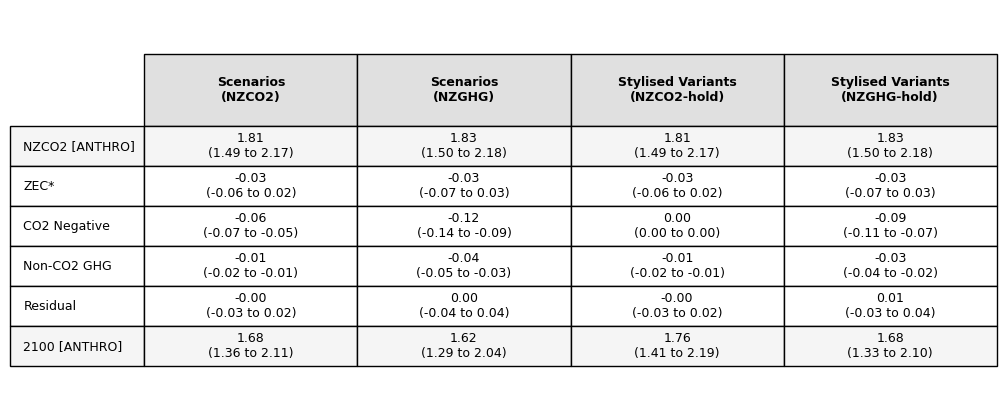

In [24]:
def fmt_decomposition(p50, p17, p83):
    return f"{p50:.2f}\n({p17:.2f} to {p83:.2f})"


rename_map = {
    "Scenarios (NZCO2)":              "Scenarios\n(NZCO2)",
    "Scenarios (NZGHG)":              "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

decomposition_rows = [
    ("NZCO2 [ANTHRO]", "endpoint", "nzco2"),
    ("ZEC*", "component", "CO2_NZCO2"),
    ("CO2 Negative", "component", "CO2_Negative"),
    ("Non-CO2 GHG", "component", "NonCO2_GHG"),
    ("Residual", "component", "Residual"),
    ("2100 [ANTHRO]", "endpoint", "y2100"),
]

table_data = {}
for row_label, kind, key in decomposition_rows:
    row_vals = []
    for group in groups:
        if kind == "endpoint":
            s = endpoint_stats[key][group]
        else:
            s = delta_stats[key][group]
        row_vals.append(fmt_decomposition(s["p50"], s["p17"], s["p83"]))
    table_data[row_label] = row_vals

decomposition_table = pd.DataFrame(table_data, index=groups).T
decomposition_table.columns = decomposition_table.columns.map(rename_map)

n_rows = len(decomposition_table)
n_cols = len(decomposition_table.columns)

fig, ax = plt.subplots(figsize=(11, n_rows * 0.7 + 1))
ax.axis("off")
table = ax.table(
    cellText=decomposition_table.values,
    colLabels=decomposition_table.columns,
    rowLabels=list(decomposition_table.index),
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.4)

header_height = 0.18
for col_idx in range(n_cols):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

for row_idx in [1, n_rows]:
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_facecolor("#f5f5f5")
    table[row_idx, -1].set_facecolor("#f5f5f5")

plt.savefig(PLOT_FOLDER / "503_Table_Figure_3.png", dpi=300, bbox_inches="tight")
plt.show()